# Word2Vec — Skip-gram + Negative Sampling (Pure NumPy)

**Dataset:** WikiText-2 (Salesforce Research)  
**Architecture:** Skip-gram with negative sampling, online SGD with linear lr decay  
**Implementation:** Pure NumPy, following the original `word2vec.c` by Mikolov et al.

**References:**
- Mikolov et al., *Efficient Estimation of Word Representations in Vector Space* (2013)
- Mikolov et al., *Distributed Representations of Words and Phrases and their Compositionality* (2013)
- [Original C implementation](https://github.com/tmikolov/word2vec/blob/master/word2vec.c)

## 1. Dataset analysis

The official WikiText-2 dataset from Salesforce Research was used. To avoid forcing the reviewer to use HF_TOKEN, the dataset is saved as `wikitext-2-v1.txt`.

In [14]:
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random

import os
# Try both paths — works for repo structure and flat Colab layout
for path in ["data/wikitext-2-v1.txt", "wikitext-2-v1.txt"]:
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            raw_text = f.read()
        print(f"Loaded from: {path}")
        break
else:
    print("ERROR: wikitext-2-v1.txt not found.")

lines = raw_text.split("\n")
print("First 10 lines of raw text:")
for i, line in enumerate(lines[:10]):
    print(f"{i:3d}: {repr(line)}")

Loaded from: data/wikitext-2-v1.txt
First 10 lines of raw text:
  0: ''
  1: ' = Valkyria Chronicles III = '
  2: ''
  3: ''
  4: ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . <unk> the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . '
  5: ''
  6: " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the 

### Tokenization and word counts

In [15]:
def clean_text(raw_text):
    text = raw_text.lower()
    text = text.replace("<unk>", " ")
    text = re.sub(r"^=.*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^a-z]", " ", text)
    tokens = text.split()
    words = [t for t in tokens if len(t) > 1]
    return words

words = clean_text(raw_text)
counts = Counter(words)

print(f"Total tokens:  {len(words):>10,}")
print(f"Unique words:  {len(counts):>10,}")
print()
for word, count in counts.most_common(20):
    print(f"    {word:18s}  {count:>8,}")

Total tokens:   1,575,674
Unique words:      27,201

    the                  130,768
    of                    57,030
    and                   50,735
    in                    45,015
    to                    39,521
    was                   21,008
    on                    15,151
    as                    15,058
    that                  14,351
    for                   13,794
    with                  13,012
    by                    12,718
    is                    11,691
    it                     9,273
    from                   9,229
    at                     9,070
    his                    9,019
    he                     8,711
    were                   7,334
    an                     6,250


Cleaning removes apostrophes and single-letter characters. This splits contractions like "wasn't" into "wasn" and "t". Below is a comparison showing the impact is small relative to the base forms.

In [16]:
pairs = [("wasn", "was"), ("weren", "were"), ("doesn", "does"),
         ("don", "do"), ("hasn", "has"), ("haven", "have")]
print(f"  {'fragment':10s} {'count':>7s}   {'base form':10s} {'count':>7s}   ratio")
print("-" * 60)
for fragment, base in pairs:
    fc, bc = counts[fragment], counts[base]
    print(f"  {fragment:10s} {fc:>7,}   {base:10s} {bc:>7,}   {fc/bc:.1%}")

  fragment     count   base form    count   ratio
------------------------------------------------------------
  wasn            58   was         21,008   0.3%
  weren            7   were         7,334   0.1%
  doesn           63   does           342   18.4%
  don            258   do             630   41.0%
  hasn             5   has          3,325   0.2%
  haven          118   have         3,470   3.4%


### Frequency distribution

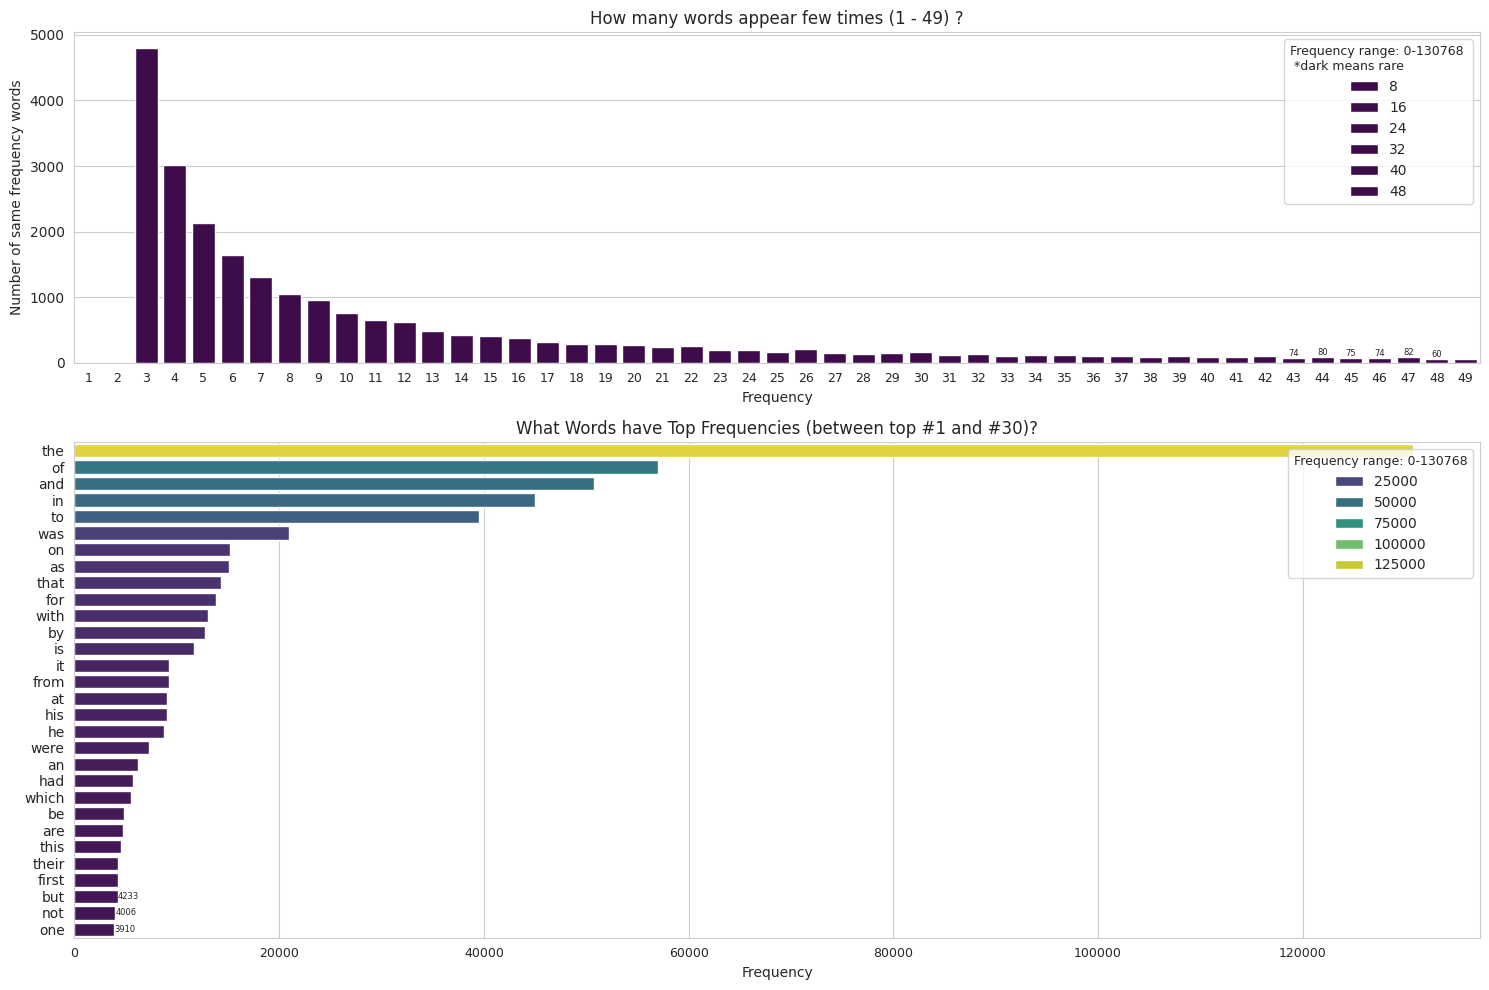

In [17]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.5])
sns.set_style("whitegrid")
plt.subplots_adjust(hspace=0.4)

# How many words appear 1..49 times?
start, end = 1, 50
frequency_of_frequencies = Counter(counts.values())
x_freq = list(range(start, end))
y_num_words = [frequency_of_frequencies.get(i, 0) for i in x_freq]

ax = plt.subplot(gs[0])
ax = sns.barplot(x=x_freq, y=y_num_words, palette="viridis", hue=x_freq,
                 hue_norm=plt.Normalize(vmin=min(frequency_of_frequencies), vmax=max(frequency_of_frequencies)))
all_bars = ax.patches
tail_indices = list(range(end - len(x_freq)//5, end))
random_tail_bars = random.sample(tail_indices, min(len(x_freq)//7, len(tail_indices)))
for i in random_tail_bars:
    bar = all_bars[i]
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=6, rotation=0)
plt.xticks(rotation=0, fontsize=9)
plt.title(f"How many words appear few times ({x_freq[0]} - {x_freq[-1]}) ?")
plt.ylabel("Number of same frequency words")
plt.xlabel(f"Frequency")
ax.legend(loc='upper right', title=f'Frequency range: 0-{max(counts.values())} \n *dark means rare',
          title_fontsize=9)

# Top 30 words
start, end = 0, 30
top_words_data = counts.most_common(end)
words_list, counts_list = zip(*top_words_data)

ax2 = plt.subplot(gs[1])
ax2 = sns.barplot(y=list(words_list)[start:], x=list(counts_list)[start:], palette="viridis",
                 hue=list(counts_list)[start:],
                 hue_norm=plt.Normalize(vmin=min(frequency_of_frequencies), vmax=max(frequency_of_frequencies)))
all_bars = ax2.patches
tail_indices = list(range(0, end//5))
random_tail_bars = random.sample(tail_indices, min(3, len(tail_indices)))
for i in random_tail_bars:
    bar = all_bars[i]
    height = bar.get_width()
    if height > 0:
        ax2.text(height, bar.get_y() + bar.get_height()/2.,
                f'{int(height)}',
                ha='left', va='center', fontsize=6, rotation=0)
plt.xticks(rotation=0, fontsize=9)
plt.title(f"What Words have Top Frequencies (between top #{start+1} and #{end})?")
plt.xlabel("Frequency")
ax2.legend(loc='upper right', title=f'Frequency range: 0-{max(counts.values())}',
          title_fontsize=9)
plt.tight_layout()
plt.show()

### Zipf's law

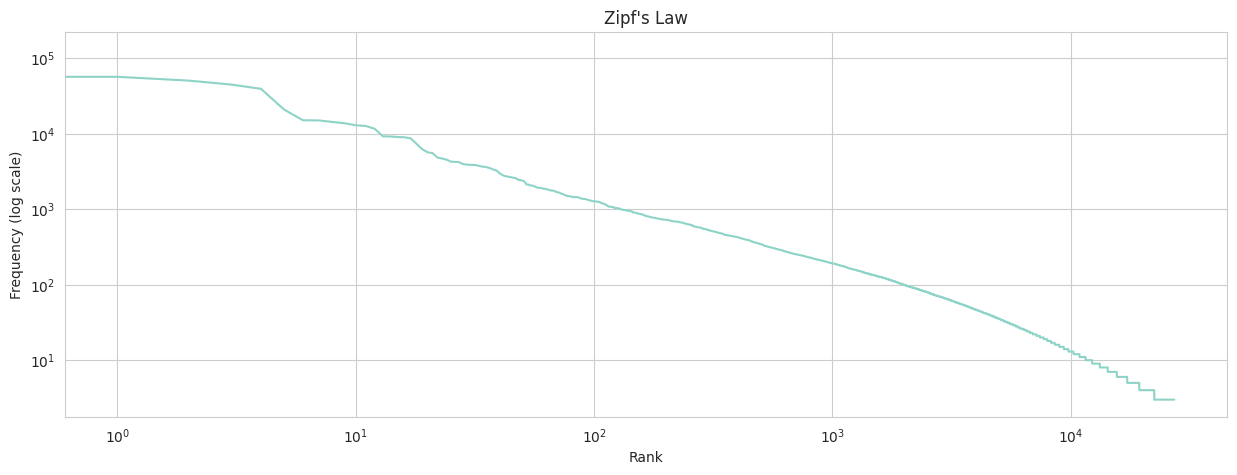

In [18]:
frequencies = [count for word, count in counts.most_common()]
plt.figure(figsize=(15, 5))
plt.loglog(frequencies, base=10)
plt.xlabel("Rank")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law")
plt.grid(True)
plt.show()

### Impact of min_count filtering

In [19]:
n = 5
count_left = len([word for word, count in counts.items() if count >= n])

total_tokens = sum(counts.values())
kept_tokens = sum(count for word, count in counts.items() if count >= n)

text_loss = (1 - kept_tokens / total_tokens) * 100
vocab_loss = (1 - count_left / len(counts)) * 100

print(f"Unique words (total):              {len(counts):>8,}")
print(f"Unique words with frequency >= {n}:  {count_left:>8,}")
print(f"Vocabulary reduced by:             {vocab_loss:>7.1f}%")
print(f"Text volume lost:                  {text_loss:>7.2f}%")

Unique words (total):                27,201
Unique words with frequency >= 5:    19,381
Vocabulary reduced by:                28.7%
Text volume lost:                     1.68%


The dataset follows Zipf's law — a small number of words account for most of the text, while the majority of unique words appear only a few times. Filtering words with frequency < 5 removes a large portion of the vocabulary but less than 2% of the total text volume. This significantly reduces the embedding matrix size while preserving nearly all contextual information for training.

## 2. Load trained embeddings

In [20]:
embeddings = np.load("embeddings.npy")
vocab = np.load("vocab.npy", allow_pickle=True)
vocab_counts = np.load("vocab_counts.npy")
losses = np.load("losses.npy")

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"Vocab: {len(vocab):,}, Embedding dim: {embeddings.shape[1]}")
print(f"vocab_counts shape: {vocab_counts.shape}")

Vocab: 19,381, Embedding dim: 100
vocab_counts shape: (19381,)


In [21]:
# helpers
def check_word(word):
    if word not in word2idx:
        print(f"Warning: Word '{word}' not found in vocabulary.")
        return 1
    return 0

def show_sim(search_list):
    for word in search_list:
        print(f"\n{word}:")
        for w, s in most_similar(word, top_n=5):
            print(f"  {w:20s} {s:.4f}")

def show_analogy(tests, top_n=5):
    for test in tests:
        a, b, c = test
        print(f"\n{a} - {b} + {c} =")
        for item in analogy(a, b, c, top_n):
            print(f"  {item[0]:20s} {item[1]:.4f}")

### Nearest neighbours (cosine similarity)

In [22]:
def most_similar(word, top_n=10):
    if check_word(word):
        return []

    idx = word2idx[word]
    vec = embeddings[idx]
    norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec)
    sims = embeddings @ vec / (norms + 1e-7)
    best = np.argsort(sims)[::-1][1:top_n+1]
    return [(idx2word[i], round(float(sims[i]), 4)) for i in best]


tests = ["king", "computer", "history", "mother", "money"]
show_sim(tests)


king:
  lord                 0.7972
  odaenathus           0.7899
  emperor              0.7755
  throne               0.7711
  leinster             0.7710

computer:
  gaming               0.8333
  graphics             0.8274
  multiplayer          0.8103
  online               0.8022
  visual               0.8022

history:
  landmark             0.6945
  geography            0.6925
  populous             0.6841
  calendar             0.6734
  assessment           0.6733

mother:
  husband              0.8769
  father               0.8743
  daughter             0.8711
  wife                 0.8294
  marriage             0.8193

money:
  pay                  0.8244
  tickets              0.7784
  failing              0.7764
  opportunity          0.7752
  paid                 0.7681


### Word analogies

In [23]:
def analogy(a, b, c, top_n=5):
  """a to b as c to ... """
  if sum([check_word(word) for word in [a,b,c]]):
    return []
  vec = embeddings[word2idx[a]] - embeddings[word2idx[b]] + embeddings[word2idx[c]]
  norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec)
  sims = embeddings @ vec / (norms + 1e-7)

  for w in [a,b,c]:
    sims[word2idx[w]] = -1
  best = np.argsort(sims)[::-1][:top_n]
  return [(idx2word[i], round(float(sims[i]), 4)) for i in best]


tests = [
    ("king", "man", "woman"),
    ("germany", "berlin", "london"),
    ("germany", "beer", "tea"),
    ("hockey", "ice", "grass"),
    ("poet", "novel", "music"),
]
show_analogy(tests)


king - man + woman =
  hairan               0.7605
  throne               0.7276
  ruler                0.7258
  odaenathus           0.7119
  lord                 0.7099

germany - berlin + london =
  italy                0.7678
  switzerland          0.7534
  netherlands          0.7521
  sydney               0.7496
  austria              0.7402

germany - beer + tea =
  austria              0.8358
  turkey               0.8072
  venezuela            0.8020
  finland              0.7999
  russia               0.7963

hockey - ice + grass =
  collegiate           0.8355
  golf                 0.8272
  lions                0.8259
  sports               0.8219
  paralympic           0.8153

poet - novel + music =
  jazz                 0.6976
  musicians            0.6950
  folk                 0.6819
  pop                  0.6810
  artists              0.6762


### Training loss

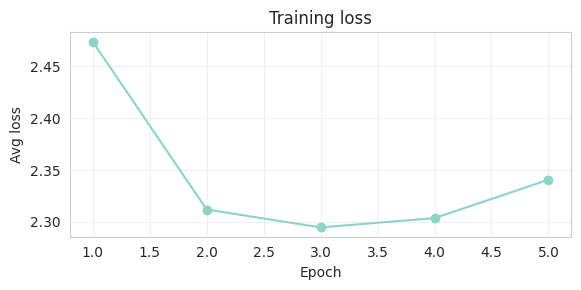

In [24]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses) + 1), losses, "o-")
plt.xlabel("Epoch")
plt.ylabel("Avg loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### t-SNE visualisation

top_vecs shape: (200, 100)


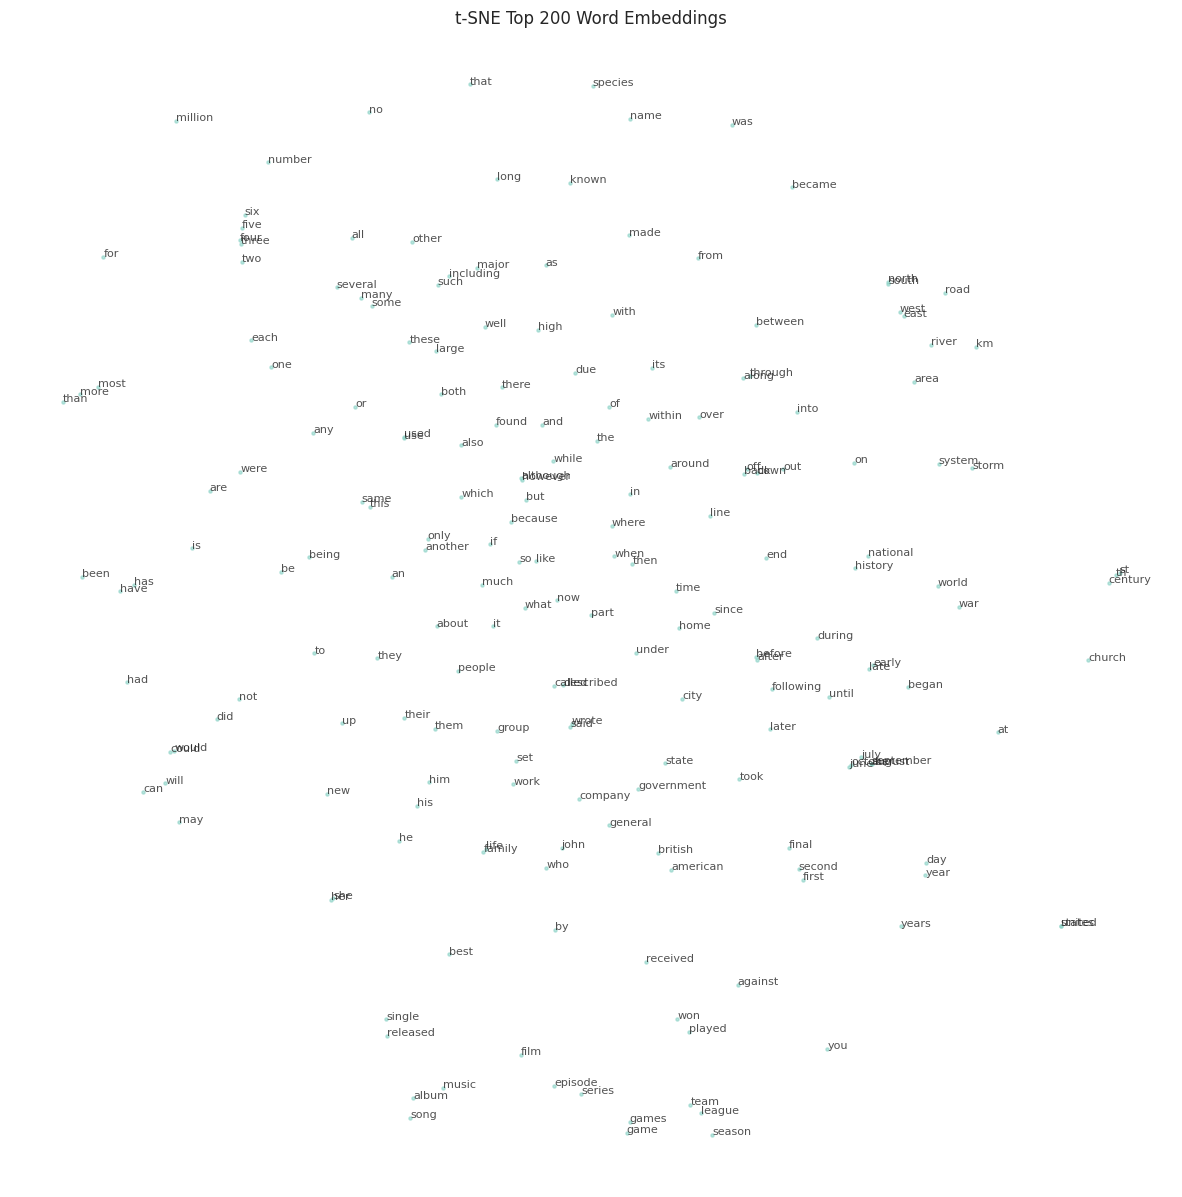

In [25]:
from sklearn.manifold import TSNE


top_k = 200
top_indices = np.argsort(vocab_counts)[::-1][:top_k]
top_words = [idx2word[i]  for i in top_indices]
top_vecs = embeddings[top_indices]

print(f"top_vecs shape: {top_vecs.shape}")

tsne = TSNE(n_components=2,  random_state=42, perplexity=30, max_iter=1000)
vecs_2d_tsne = tsne.fit_transform(top_vecs)

plt.figure(figsize=(15, 15))
plt.scatter(vecs_2d_tsne[:, 0], vecs_2d_tsne[:, 1], s=5, alpha=0.6)
for i, w in enumerate(top_words):
    plt.annotate(w, (vecs_2d_tsne[i, 0], vecs_2d_tsne[i, 1]), fontsize=8, alpha=0.8)
plt.title(f"t-SNE Top {top_k} Word Embeddings")
plt.axis("off")
plt.show()

### PCA visualisation

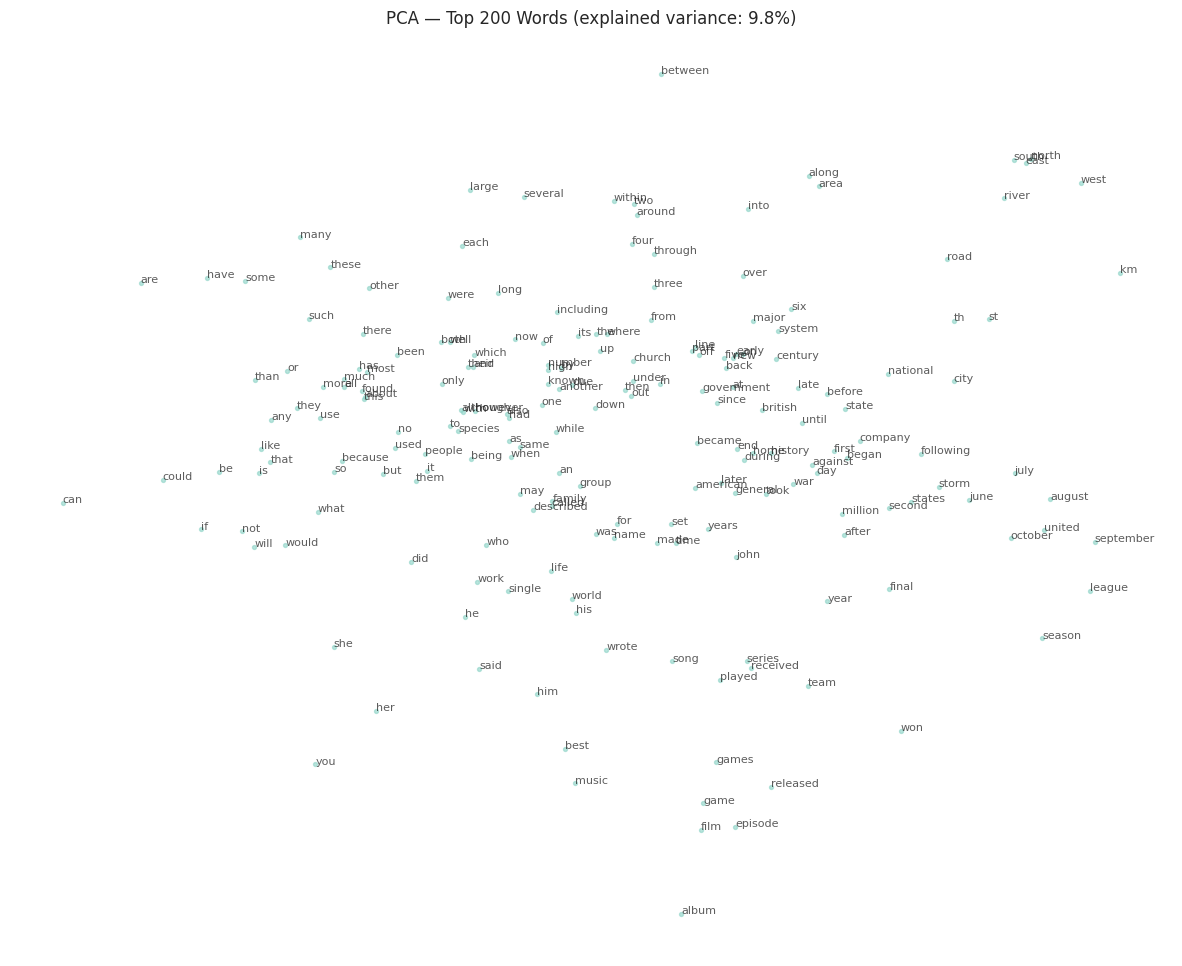

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
vecs_2d_pca = pca.fit_transform(top_vecs)

plt.figure(figsize=(15, 12))
plt.scatter(vecs_2d_pca[:, 0], vecs_2d_pca[:, 1], s=8, alpha=0.6)
for i, w in enumerate(top_words):
    plt.annotate(w, (vecs_2d_pca[i, 0], vecs_2d_pca[i, 1]), fontsize=8, alpha=0.75)
plt.title(f"PCA — Top {top_k} Words (explained variance: {pca.explained_variance_ratio_.sum():.1%})")
plt.axis("off")
plt.show()